# Grundlagen der Künstlichen Intelligenz.
# Exercise 4. Genetic Algorithms

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 4 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

## Problem Setup

### City Coordinates

- Create a set of 10 cities with random `(x, y)` coordinates.
- Represent these coordinates as a dictionary or a list of tuples.

City 0: (37.454011884736246, 95.07143064099162)
City 1: (73.1993941811405, 59.86584841970366)
City 2: (15.601864044243651, 15.599452033620265)
City 3: (5.8083612168199465, 86.61761457749351)
City 4: (60.11150117432088, 70.80725777960456)
City 5: (2.0584494295802447, 96.99098521619943)
City 6: (83.24426408004217, 21.233911067827616)
City 7: (18.182496720710063, 18.34045098534338)
City 8: (30.42422429595377, 52.475643163223786)
City 9: (43.194501864211574, 29.122914019804192)
City 10: (61.18528947223795, 13.949386065204184)
City 11: (29.214464853521815, 36.63618432936917)
City 12: (45.606998421703594, 78.51759613930136)
City 13: (19.967378215835975, 51.42344384136116)
City 14: (59.24145688620425, 4.645041271999773)
City 15: (60.75448519014384, 17.052412368729154)
City 16: (6.505159298527952, 94.88855372533332)
City 17: (96.56320330745594, 80.83973481164611)
City 18: (30.46137691733707, 9.767211400638388)
City 19: (68.42330265121569, 44.01524937396013)
City 20: (12.203823484477883, 49.517

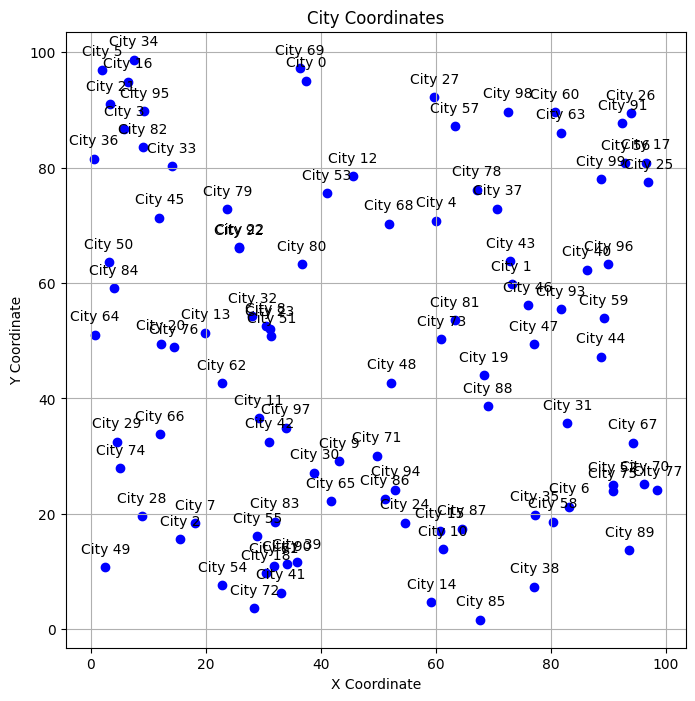

In [33]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility

num_cities = 100
cities = {}
for i in range(num_cities):
    cities[i] = (np.random.uniform(0, 100), np.random.uniform(0, 100))

for city_id, coords in cities.items():
    print(f"City {city_id}: {coords}")

plt.figure(figsize=(8, 8))
x_coords = [coord[0] for coord in cities.values()]
y_coords = [coord[1] for coord in cities.values()]
plt.scatter(x_coords, y_coords, color='blue')
for city_id, (x, y) in cities.items():
    plt.annotate(f"City {city_id}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')
plt.title("City Coordinates")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid()
plt.show()


### Distance Calculation

- Implement a function to calculate the Euclidean distance between two cities.
- Implement a function to calculate the total distance of a route (a sequence of cities).

In [3]:
def euclidean_distance(city1, city2):
    return np.sqrt(np.sum((np.array(city1) - np.array(city2)) ** 2))

def total_distance(route, cities):
    distance = 0
    for i in range(len(route)):
        from_city = cities[route[i]]
        to_city = cities[route[(i + 1) % len(route)]]  # Wrap around to the first city
        distance += euclidean_distance(from_city, to_city)
    return distance

## Genetic Algorithm Implementation

### Chromosome Representation

- Chromosome Representation in Detail:
    -  Represent a route (chromosome) as a list of city indices. If we have `n` cities, a chromosome will be a list of `n` unique integers, where each integer corresponds to the index of a city.
    
        For example, if we have cities `A`, `B`, `C`, `D`, and `E`, a chromosome `[2, 0, 3, 1, 4]` means the route is: City C, City A, City D, City B, City E.
    - This representation is suitable for the TSP because it directly encodes the order in which cities are visited, ensuring each city is visited exactly once.
- Implement a function to generate a random initial population of routes.

In [9]:
def initial_population(pop_size, num_cities):
    population = []
    for _ in range(pop_size):
        route = np.random.permutation(num_cities).tolist()
        population.append(route)
    return population

population_size = 5
population = initial_population(population_size, num_cities)
for i, route in enumerate(population):
    print(f"Route {i}: {route}\n\t- Total Distance: {total_distance(route, cities):.2f}")

Route 0: [4, 2, 7, 0, 6, 3, 5, 8, 9, 1]
	- Total Distance: 492.47
Route 1: [5, 2, 7, 3, 0, 8, 9, 6, 1, 4]
	- Total Distance: 419.69
Route 2: [1, 5, 2, 4, 3, 7, 9, 6, 8, 0]
	- Total Distance: 582.39
Route 3: [3, 1, 4, 5, 8, 6, 9, 7, 0, 2]
	- Total Distance: 568.69
Route 4: [2, 4, 5, 1, 7, 0, 9, 3, 8, 6]
	- Total Distance: 669.00


### Fitness Function

Implement a fitness function that calculates the inverse of the total route distance
(shorter routes have higher fitness).

In [10]:
def calculate_fitness(route, cities):
    return 1 / total_distance(route, cities)

### Selection

Implement a selection method (e.g., tournament selection or roulette wheel selection) to choose parent routes for crossover.

In [11]:
def tournament_selection(population, fitnesses, tournament_size=3):
    selected_indices = np.random.choice(range(len(population)), tournament_size, replace=False)
    best_index = selected_indices[0]
    for idx in selected_indices[1:]:
        if fitnesses[idx] > fitnesses[best_index]:
            best_index = idx
    return population[best_index]

def roulette_wheel_selection(population, fitnesses):
    total_fitness = sum(fitnesses)
    pick = np.random.uniform(0, total_fitness)
    current = 0
    for i, fitness in enumerate(fitnesses):
        current += fitness
        if current > pick:
            return population[i]

### Crossover

Implement a suitable crossover operator for the TSP (e.g., ordered crossover or partially mapped crossover).

In [25]:
from typing import List
import random
def ordered_crossover(parent1: List[int], parent2: List[int]) -> List[int]:
    """
    Führt Ordered Crossover zwischen zwei Eltern durch # Performs Ordered Crossover between two parents
    Ein Teilbereich wird vom ersten Elternteil kopiert # A subrange is copied from the first parent
    und die restlichen Positionen werden mit Werten vom zweiten Elternteil gefüllt # and the remaining positions are filled with values from the second parent
    Die Reihenfolge der Werte im zweiten Elternteil wird beibehalten # The order of values in the second parent is preserved
    und Duplikate werden vermieden # and duplicates are avoided
    
    Args:
        parent1: Erste Elternroute # First parent route
        parent2: Zweite Elternroute # Second parent route
        
    Returns:
        Kind-Route
    """
    # Bestimme zufälligen Teilbereich zwischen zwei Indizes # Determine random subrange between two indices
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    
    # Kopiere den Teilbereich vom ersten Elternteil # Copy the subrange from the first parent
    child = [-1] * size
    for i in range(start, end + 1):
        child[i] = parent1[i]
    
    # Fülle die restlichen Positionen mit Werten vom zweiten Elternteil # Fill the remaining positions with values from the second parent
    # unter Beibehaltung der Reihenfolge und ohne Duplikate # while preserving the order and avoiding duplicates
    curr_parent2_pos = 0
    for i in range(size):
        if child[i] == -1:  # Position ist noch nicht besetzt # Position is not yet occupied
            # Finde den nächsten Wert in parent2, der noch nicht in child ist # Find the next value in parent2 that is not yet in child
            while parent2[curr_parent2_pos] in child:
                curr_parent2_pos = (curr_parent2_pos + 1) % size
            child[i] = parent2[curr_parent2_pos]
            curr_parent2_pos = (curr_parent2_pos + 1) % size
    
    return child

# // TODO: Ayuda

### Mutation

Implement a suitable mutation operator for the TSP (e.g., swap mutation or inversion
mutation).

In [19]:
def swap_mutation(route, mutation_rate=0.1):
    if np.random.random() < mutation_rate:
        idx1, idx2 = np.random.choice(len(route), 2, replace=False)
        route[idx1], route[idx2] = route[idx2], route[idx1]
    return route

def inversion_mutation(route, mutation_rate=0.1):
    if np.random.random() < mutation_rate:
        idx1, idx2 = sorted(np.random.choice(len(route), 2, replace=False))
        route[idx1:idx2] = route[idx1:idx2][::-1]
    return route

### Genetic Algorithm Loop

- Implement the main loop of the genetic algorithm, including population initialization,
fitness evaluation, selection, crossover, and mutation.
- Run the algorithm for a specified number of generations and track the best route
found.

In [49]:
import time
def genetic_algorithm(
        cities,
        population_size=100,
        consecutive_generations=50,
        mutation_method=swap_mutation,
        mutation_rate=0.01,
        elites=5,
        crossover_method=ordered_crossover,
        selection_method=tournament_selection,
        tournament_size=3
                      ):
    population = initial_population(population_size, len(cities))
    
    best_fitness_history = []
    generation = -1
    while len(best_fitness_history) < consecutive_generations or best_fitness_history[-1] != best_fitness_history[-consecutive_generations]:
        generation += 1
        fitnesses = [calculate_fitness(route, cities) for route in population]
        
        best_fitness_idx = np.argmax(fitnesses)
        best_fitness_history.append(fitnesses[best_fitness_idx])

        if generation % 50 == 0:
            print(f"Generation {generation}:\n\t- Best Route = {population[best_fitness_idx]}\n\t- Distance = {total_distance(population[best_fitness_idx], cities):.2f}")

        new_population = []

        # Keep elites
        sorted_indices = np.argsort(fitnesses)[-elites:]
        for idx in sorted_indices:
            new_population.append(population[idx])

        # For the rest of the population, perform selection, crossover, and mutation
        while len(new_population) < population_size:
            if selection_method == tournament_selection:
                parent1 = tournament_selection(population, fitnesses, tournament_size)
                parent2 = tournament_selection(population, fitnesses, tournament_size)
            elif selection_method == roulette_wheel_selection:
                parent1 = roulette_wheel_selection(population, fitnesses)
                parent2 = roulette_wheel_selection(population, fitnesses)
            else:
                raise ValueError("Invalid selection method. Choose 'tournament' or 'roulette'.")

            child = crossover_method(parent1, parent2)

            child = mutation_method(child, mutation_rate)
            new_population.append(child)

        population = new_population

    final_fitnesses = [calculate_fitness(route, cities) for route in population]
    best_fitness_idx = np.argmax(final_fitnesses)
    return population[best_fitness_idx], best_fitness_history


start_time = time.time()
best_route, fitness_history = genetic_algorithm(
    cities,
    population_size=200,
    consecutive_generations=100,
    mutation_method=swap_mutation,
    mutation_rate=0.05,
    elites=2,
    crossover_method=ordered_crossover,
    selection_method=tournament_selection,
    tournament_size=3
)
end_time = time.time()
print(f"Best Route: {best_route}\nTotal Distance: {total_distance(best_route, cities):.2f}\nExecution Time: {end_time - start_time:.2f} seconds")
        

Generation 0:
	- Best Route = [65, 94, 14, 97, 23, 50, 59, 77, 4, 37, 13, 88, 25, 76, 82, 17, 93, 70, 75, 66, 53, 71, 49, 51, 55, 6, 54, 0, 73, 5, 79, 64, 20, 7, 36, 81, 9, 10, 15, 60, 74, 83, 84, 28, 62, 78, 95, 92, 48, 18, 40, 32, 39, 99, 67, 52, 58, 30, 87, 44, 8, 85, 1, 91, 43, 35, 46, 57, 96, 61, 11, 26, 98, 72, 34, 69, 24, 63, 21, 42, 33, 86, 41, 16, 45, 12, 3, 22, 2, 56, 89, 19, 68, 80, 38, 47, 31, 27, 29, 90]
	- Distance = 4768.95
Generation 50:
	- Best Route = [97, 11, 2, 62, 53, 27, 78, 1, 75, 80, 92, 3, 5, 49, 74, 20, 84, 76, 32, 7, 55, 18, 73, 40, 8, 33, 13, 41, 77, 35, 44, 93, 26, 47, 59, 91, 57, 46, 42, 64, 79, 69, 21, 36, 82, 34, 16, 25, 98, 56, 60, 4, 12, 66, 54, 67, 19, 52, 70, 24, 23, 95, 45, 22, 68, 30, 65, 90, 39, 96, 63, 99, 17, 0, 50, 28, 29, 58, 89, 85, 10, 14, 86, 88, 48, 87, 83, 61, 72, 9, 94, 71, 15, 38, 6, 31, 81, 43, 37, 51]
	- Distance = 2780.63
Generation 100:
	- Best Route = [97, 11, 62, 53, 27, 78, 1, 75, 73, 80, 92, 3, 5, 84, 49, 74, 20, 76, 7, 55, 18, 

## Analysis and Visualization

### Performance Analysis

-  Plot the fitness of the best route over generations.
- Discuss how the algorithm’s performance changes with different parameters (population size, crossover/mutation rates).

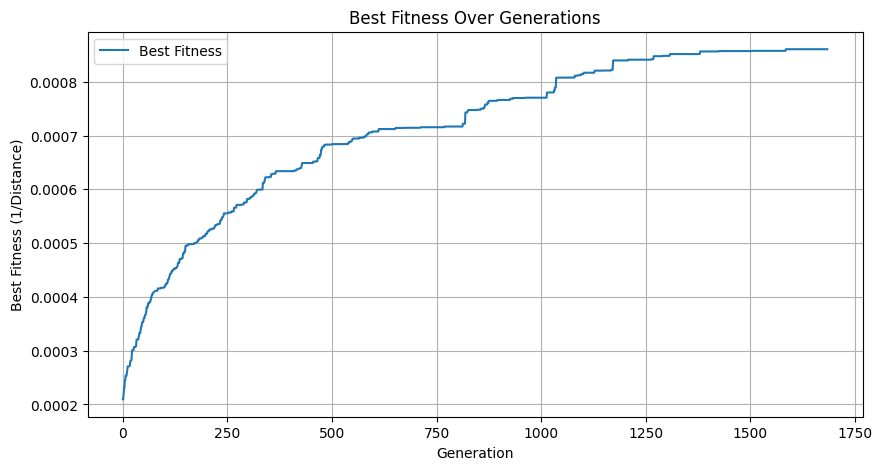

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(fitness_history, label='Best Fitness')
plt.title('Best Fitness Over Generations')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (1/Distance)')
plt.legend()
plt.grid()
plt.show()

In [43]:
parameters = {
    "Population Size": [50, 100, 200],
    "Mutation Rate": [0.005, 0.01, 0.05],
    "Elites": [1, 2, 5],
    "Tournament Size": [2, 5, 8]
}

default_params = {
    "Population Size": 100,
    "Generations": 200,
    "Mutation Rate": 0.01,
    "Elites": 2,
    "Tournament Size": 3
}

results = {}

for param_name, param_values in parameters.items():
    parameter_results = []
    for value in param_values:
        current_params = default_params.copy()
        current_params[param_name] = value
        n_runs = 3
        best_distances = []
        for _ in range(n_runs):
            _, fitness_history = genetic_algorithm(
                cities,
                population_size=current_params["Population Size"],
                generations=current_params["Generations"],
                mutation_method=swap_mutation,
                mutation_rate=current_params["Mutation Rate"],
                elites=current_params["Elites"],
                crossover_method=ordered_crossover,
                selection_method=tournament_selection,
                tournament_size=current_params["Tournament Size"]
            )
            best_distances.append(1 / fitness_history[-1])  # Convert fitness back to distance
        parameter_results.append((value, np.mean(best_distances)))
    
    results[param_name] = parameter_results


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, (param_name, param_results) in enumerate(results.items()):
    values, distances = zip(*param_results)
    axes[i].plot(values, distances, marker='o')
    axes[i].set_title(f'Effect of {param_name} on Best Distance')
    axes[i].set_xlabel(param_name)
    axes[i].set_ylabel('Best Distance')
    axes[i].grid()
plt.tight_layout()
plt.show()


Generation 0:
	- Best Route = [72, 75, 96, 71, 40, 7, 23, 88, 93, 43, 79, 21, 83, 24, 54, 78, 14, 74, 69, 66, 98, 16, 53, 80, 62, 22, 55, 35, 12, 45, 4, 27, 44, 33, 57, 2, 26, 63, 52, 60, 15, 25, 86, 65, 85, 31, 92, 11, 3, 36, 17, 18, 94, 84, 5, 56, 91, 0, 38, 6, 70, 47, 10, 90, 48, 1, 87, 20, 30, 9, 13, 97, 76, 32, 39, 42, 41, 81, 77, 49, 73, 51, 58, 61, 89, 29, 64, 67, 50, 8, 37, 46, 82, 28, 19, 34, 99, 59, 95, 68]
	- Distance = 4998.83
Generation 50:
	- Best Route = [78, 19, 98, 99, 43, 57, 22, 2, 54, 87, 48, 1, 33, 84, 64, 0, 8, 83, 18, 74, 45, 4, 27, 63, 44, 52, 60, 25, 14, 38, 50, 21, 69, 82, 12, 13, 30, 41, 80, 94, 71, 72, 97, 31, 10, 96, 26, 17, 85, 55, 7, 95, 16, 5, 79, 92, 51, 11, 20, 23, 88, 70, 37, 47, 46, 40, 86, 15, 89, 35, 65, 3, 36, 56, 91, 6, 58, 59, 93, 24, 61, 49, 29, 66, 62, 32, 76, 90, 9, 39, 42, 81, 67, 77, 75, 73, 28, 68, 53, 34]
	- Distance = 3248.46
Generation 100:
	- Best Route = [78, 19, 98, 99, 43, 57, 22, 2, 54, 87, 48, 1, 33, 84, 64, 0, 8, 83, 18, 74, 45, 

KeyboardInterrupt: 

### Route Visualization

- Visualize the best route found by the genetic algorithm on a scatter plot of the cities

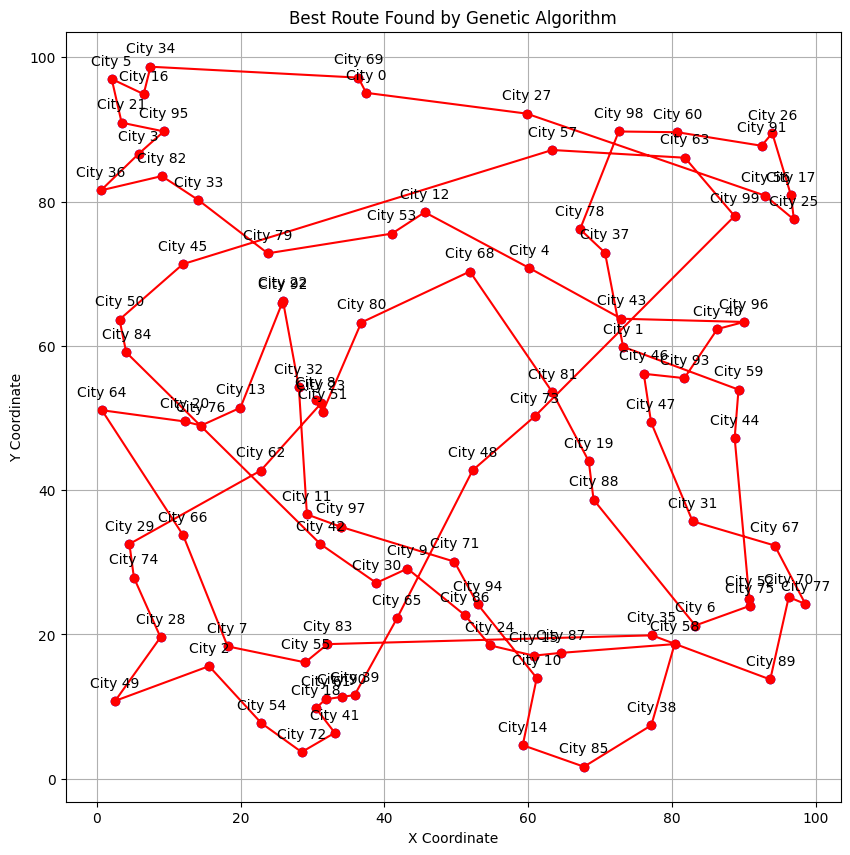

In [51]:
plt.figure(figsize=(10, 10))
for city_id, (x, y) in cities.items():
    plt.scatter(x, y, color='blue')
    plt.annotate(f"City {city_id}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')
route_coords = [cities[city_id] for city_id in best_route]
route_coords.append(cities[best_route[0]])  # Return to the starting city
route_x = [coord[0] for coord in route_coords]
route_y = [coord[1] for coord in route_coords]
plt.plot(route_x, route_y, color='red', marker='o')
plt.title("Best Route Found by Genetic Algorithm")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid()
plt.show()